In [2]:
import pandas as pd

In [2]:
df=pd.read_csv('data/cancer_data.csv')
df.head()

,age,gender,bmi,smoking,genetic_risk,physical_activity,alcohol_intake,cancer_history,diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040295,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1


In [5]:
df.columns

Index(['age', 'gender', 'bmi', 'smoking', 'genetic_risk', 'physical_activity',
       'alcohol_intake', 'cancer_history', 'diagnosis'],
      dtype='str')

In [3]:
df.isnull().sum()

age                  0
gender               0
bmi                  0
smoking              0
genetic_risk         0
physical_activity    0
alcohol_intake       0
cancer_history       0
diagnosis            0
dtype: int64

In [7]:
from sklearn.model_selection import train_test_split

x=df.drop('diagnosis',axis=1)
y=df.diagnosis

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=42)

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix

model=RandomForestClassifier()
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [13]:
y_pred=model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       233
           1       0.92      0.87      0.90       142

    accuracy                           0.92       375
   macro avg       0.92      0.91      0.92       375
weighted avg       0.92      0.92      0.92       375



# Ada boosting algorithm

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(
    n_estimators=10,#number of weak learners
    learning_rate=0.1,#contribution of each learner
    random_state=42
)

model.fit(x_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",10
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


## model evaluation

In [15]:
y_pred=model.predict(x_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.71      0.96      0.81       233
           1       0.84      0.35      0.49       142

    accuracy                           0.73       375
   macro avg       0.78      0.65      0.65       375
weighted avg       0.76      0.73      0.69       375



<Axes: >

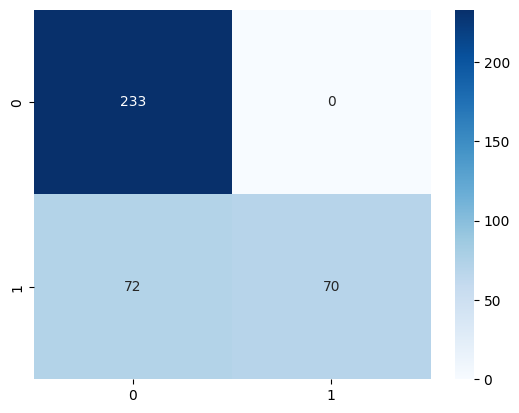

In [10]:
import seaborn as sns
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

# Gradient Boosting

In [3]:
df=pd.read_csv('data/ad_spend.csv')
df.sample(5)

,Ad Spend ($),Season,Revenue ($)
6,233,Monsoon,186
24,985,Winter,1423
111,982,Summer,1207
119,859,Summer,1052
43,761,Winter,955


In [4]:
df.shape

(200, 3)

## understanding data frame

In [10]:
g=df.groupby('Season')[['Revenue ($)','Ad Spend ($)']].mean().round(2)
g

,Revenue ($),Ad Spend ($)
Season,,
Monsoon,423.15,517.64
Summer,689.36,573.84
Winter,826.53,552.56


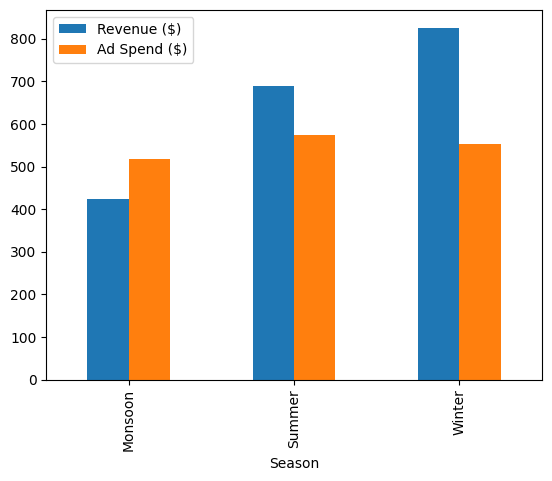

In [14]:
import matplotlib.pylab as plt
g.plot(kind="bar")
plt.show()

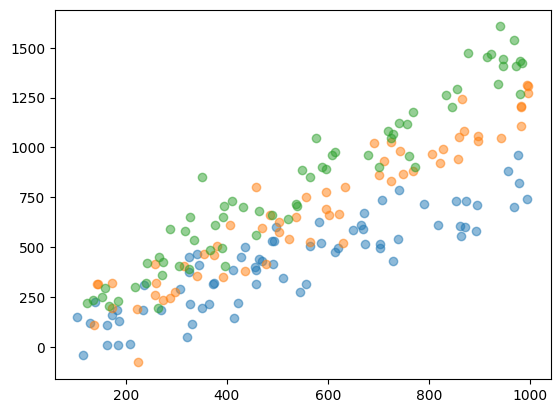

In [15]:
for season,subdf in df.groupby("Season"):
    plt.scatter(subdf['Ad Spend ($)'],subdf['Revenue ($)'],alpha=0.5)

In [16]:
df_encoded=pd.get_dummies(df,columns=['Season'],drop_first=True)

In [17]:
df_encoded.head()

,Ad Spend ($),Revenue ($),Season_Summer,Season_Winter
0,463,440,False,False
1,158,297,False,True
2,328,214,False,False
3,322,48,False,False
4,726,1048,False,True


In [18]:
from sklearn.model_selection import train_test_split
x=df_encoded.drop('Revenue ($)',axis=1)
y=df_encoded['Revenue ($)']

In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=42)

## model training

In [27]:
from sklearn.ensemble import GradientBoostingRegressor

model=GradientBoostingRegressor(
    n_estimators=65,      # Number of trees
    learning_rate=0.1,    # Contribution of each tree
    max_depth=3,          # Maximum depth of each tree
    min_samples_split=2,  # Minimum samples required to split
    min_samples_leaf=1,   # Minimum samples in a leaf
    subsample=1.0,        # Fraction of training data used
    loss='squared_error', # Loss function
    random_state=42       # Reproducible results
)
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.8879287534915072

In [29]:
y_pred=model.predict(x_test)

df_ev=pd.DataFrame({'actual':y_test,'predicted':y_pred})
df_ev.head()

,actual,predicted
95,903,952.057423
15,1047,896.081264
30,1026,886.242668
158,1203,1281.524816
128,558,667.574717


In [30]:
df_ev['diff (%)']=abs((df_ev['predicted']-df_ev['actual'])*100/df_ev['actual'])
df_ev.head()

,actual,predicted,diff (%)
95,903,952.057423,5.432716
15,1047,896.081264,14.414397
30,1026,886.242668,13.621572
158,1203,1281.524816,6.527416
128,558,667.574717,19.637046
